In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [2]:
df = pd.read_csv("HR Employee.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

df.shape

(1470, 35)

In [9]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

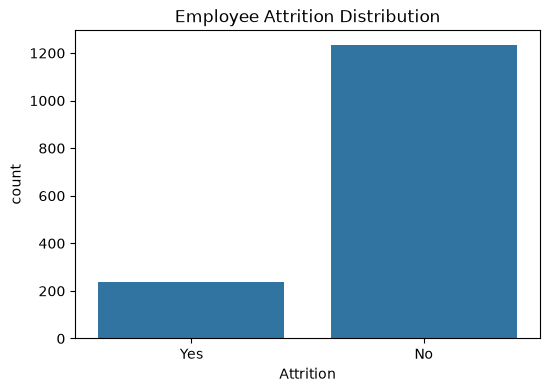

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Distribution")

plt.show()

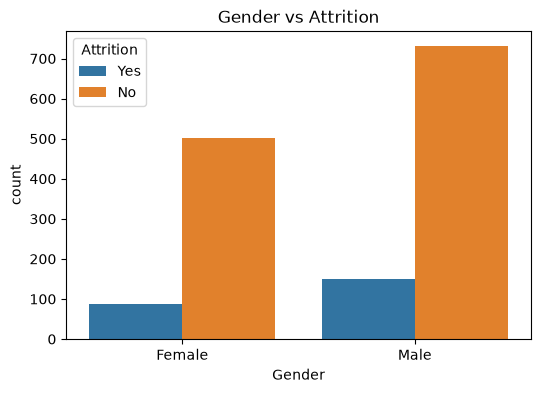

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", hue="Attrition", data=df)

plt.title("Gender vs Attrition")

plt.show()

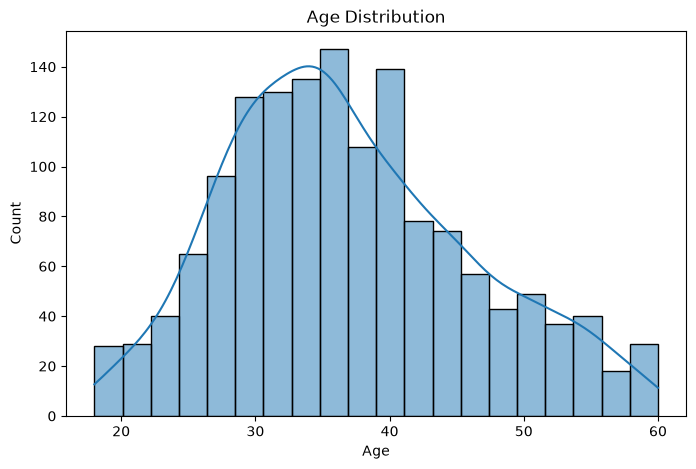

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

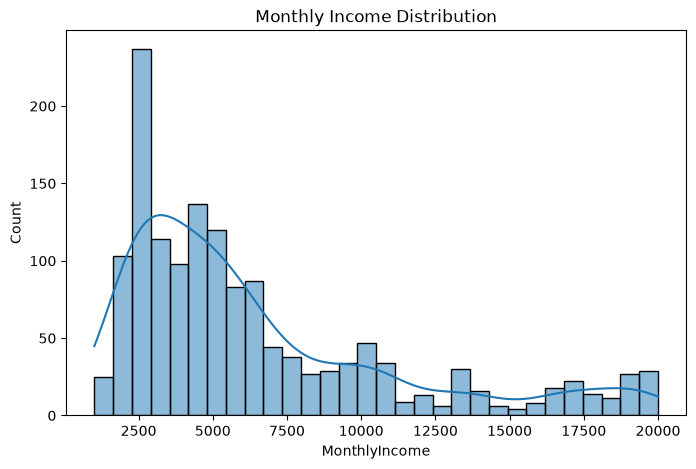

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyIncome"], bins=30, kde=True)

plt.title("Monthly Income Distribution")

plt.show()

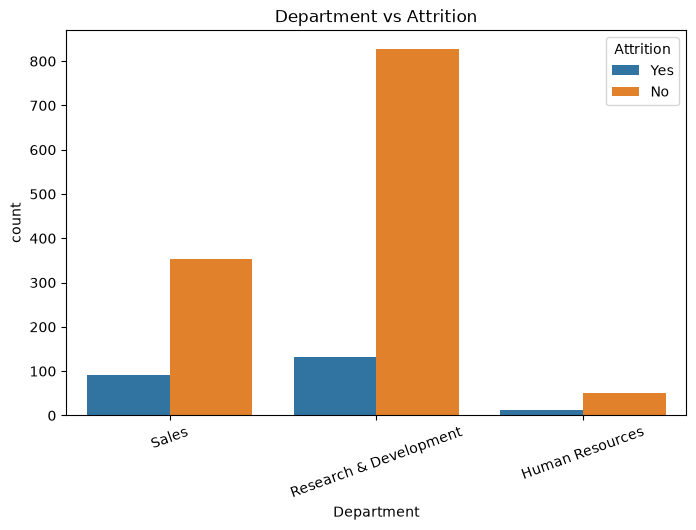

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x="Department", hue="Attrition", data=df)

plt.xticks(rotation=20)

plt.title("Department vs Attrition")

plt.show()

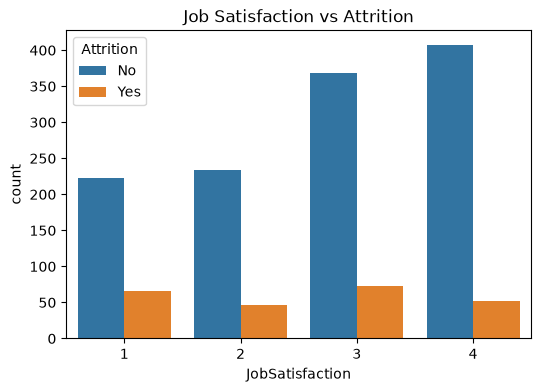

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)

plt.title("Job Satisfaction vs Attrition")

plt.show()

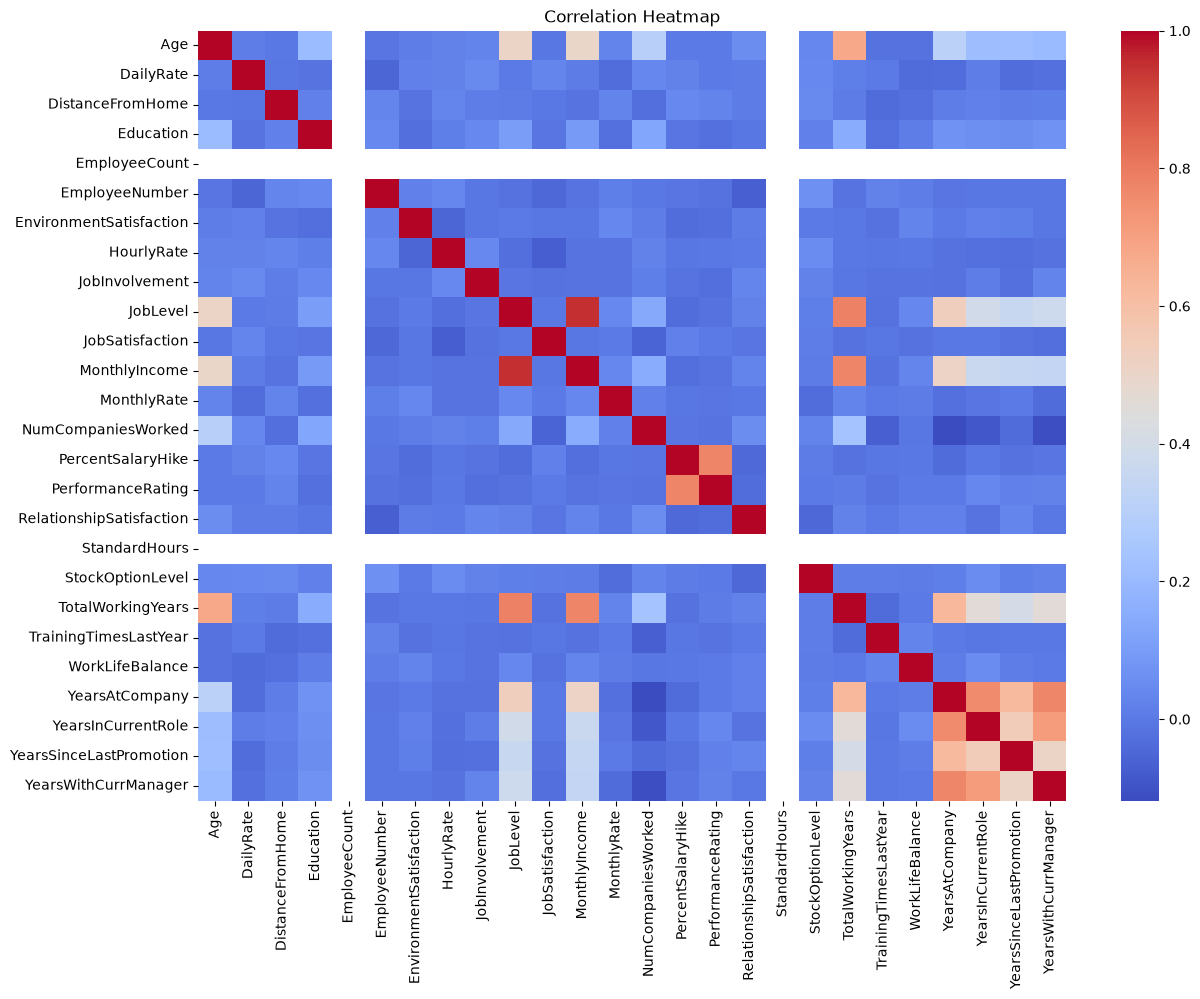

In [17]:
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [18]:
df["Attrition"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

C:\Users\chaud\AppData\Local\Temp\ipykernel_11908\1608089833.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [20]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.891156462585034
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.68      0.33      0.45        39

    accuracy                           0.89       294
   macro avg       0.79      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294



In [26]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7653061224489796
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       255
           1       0.16      0.18      0.17        39

    accuracy                           0.77       294
   macro avg       0.52      0.52      0.52       294
weighted avg       0.78      0.77      0.77       294



In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8639455782312925
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.44      0.10      0.17        39

    accuracy                           0.86       294
   macro avg       0.66      0.54      0.55       294
weighted avg       0.82      0.86      0.83       294



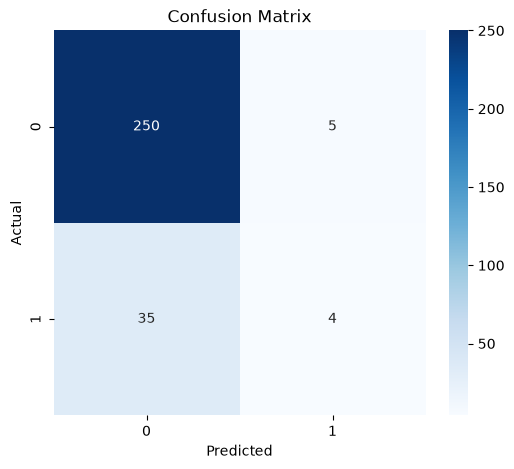

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [29]:
import joblib

joblib.dump(rf, "model.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(X.columns.tolist(), "feature_names.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [30]:
import pandas as pd

original_df = pd.read_csv("HR Employee.csv")

for col in original_df.select_dtypes(include="object").columns:
    print(col)
    print(original_df[col].unique())
    print("-"*50)

Attrition
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
BusinessTravel
<ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str
--------------------------------------------------
Department
<ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
--------------------------------------------------
EducationField
<ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str
--------------------------------------------------
Gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
JobRole
<ArrowStringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Re

C:\Users\chaud\AppData\Local\Temp\ipykernel_11908\1413931624.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in original_df.select_dtypes(include="object").columns:


In [31]:
selected_features = [

    "Age",
    "BusinessTravel",
    "Department",
    "DistanceFromHome",
    "Education",
    "EducationField",
    "EnvironmentSatisfaction",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "MonthlyIncome",
    "OverTime",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "YearsAtCompany",
    "YearsSinceLastPromotion"

]

X = df[selected_features]

y = df["Attrition"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, pred))

Accuracy : 0.8707482993197279


In [35]:
import joblib

joblib.dump(rf, "model.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(selected_features, "feature_names.pkl")

print("Model Saved Successfully")

Model Saved Successfully
